<a href="https://colab.research.google.com/github/devpatel0005/SMS-Spam-Detection/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

# --- Kaggle API setup and dataset download for Colab environment ---

# Install Kaggle API client
!pip install kaggle --quiet

# Create .kaggle directory and move kaggle.json for authentication
# The kaggle.json file is expected to be present at /content/kaggle.json as per kernel state.
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download the 'SMS Spam Collection Dataset' to the current directory
# The dataset ID is 'uciml/sms-spam-collection-dataset'
!kaggle datasets download -d uciml/sms-spam-collection-dataset -p .

# Unzip the downloaded file. The zip file usually contains 'spam.csv'.
# The downloaded file is typically named after the dataset ID, so 'sms-spam-collection-dataset.zip'.
!unzip -o sms-spam-collection-dataset.zip

# Verify the contents after unzipping
print("Files in current directory after download and extraction:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# --- End of Kaggle API setup ---

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
  0% 0.00/211k [00:00<?, ?B/s]
100% 211k/211k [00:00<00:00, 475MB/s]
Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                
Files in current directory after download and extraction:
./sms-spam-collection-dataset.zip
./spam.csv
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/.last_update_check.json
./.config/active_config
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/default_configs.db
./.config/configurations/config_default
./.config/logs/2026.02.06/14.31.44.938153.log
./.config/logs/2026.02.06/14.30.32.592228.log
./.config/logs/2026.02.06/14.31.35.535753.log
./.config/logs/2026.02.06/14.31.19.332851.log
./.config/logs/2026.02.06/14.31.28.771044.log
./.config/logs/2026.02.06/14.31.45.734270.log
./sample_data/anscombe.json
./sample_data/README.md
./sample_da

In [40]:
import pandas as pd
# Load the spam.csv file from the current directory after extraction
messages = pd.read_csv('spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
display(messages.head())

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [41]:
messages.columns=["label", "message"]

In [42]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [43]:
import nltk

In [44]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
ps = WordNetLemmatizer()

In [45]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
corpus=[]
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()

    review = [ps.lemmatize(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer()
X= cv.fit_transform(corpus).toarray()

In [48]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
messages['label'] = encoder.fit_transform(messages['label'])



In [49]:
y = messages['label']

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)


from sklearn.ensemble import RandomForestClassifier
spam_detect_model = RandomForestClassifier().fit(X_train, y_train)

y_pred_train=spam_detect_model.predict(X_train)
y_pred_test=spam_detect_model.predict(X_test)


In [51]:
from sklearn.metrics import classification_report
print("training report: ",classification_report(y_train,y_pred_train))
print("test report: ",classification_report(y_test,y_pred_test))


training report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00      3876
           1       1.00      1.00      1.00       581

    accuracy                           1.00      4457
   macro avg       1.00      1.00      1.00      4457
weighted avg       1.00      1.00      1.00      4457

test report:                precision    recall  f1-score   support

           0       0.97      1.00      0.98       949
           1       0.99      0.82      0.90       166

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



This model is overfitting

# Using Neural Network

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [53]:
input_dim = X.shape[1]
print(f"Input dimension for the neural network (number of features): {input_dim}")

Input dimension for the neural network (number of features): 7023


In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = Sequential()
model.add(Dense(units=128, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.5))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       899,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 907,393 (3.46 MB)

 Trainable params: 907,393 (3.46 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model compiled successfully with Adam optimizer, binary crossentropy loss, and accuracy metric.


In [59]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
print("Model training complete.")

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8273 - loss: 0.5163 - val_accuracy: 0.8643 - val_loss: 0.1933
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9081 - loss: 0.1503 - val_accuracy: 0.9776 - val_loss: 0.0780
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9883 - loss: 0.0444 - val_accuracy: 0.9798 - val_loss: 0.0642
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9926 - loss: 0.0245 - val_accuracy: 0.9809 - val_loss: 0.0688
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9966 - loss: 0.0105 - val_accuracy: 0.9798 - val_loss: 0.0700
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9991 - loss: 0.0051 - val_accuracy: 0.9809 - val_loss: 0.0877
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9809 - val_loss: 0.0884
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0

In [60]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9725 - loss: 0.1512
Test Loss: 0.1187
Test Accuracy: 0.9776


In [61]:
from sklearn.metrics import classification_report

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Classification Report for Neural Network Model:")
print(classification_report(y_test, y_pred_nn))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Classification Report for Neural Network Model:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       949
           1       1.00      0.85      0.92       166

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



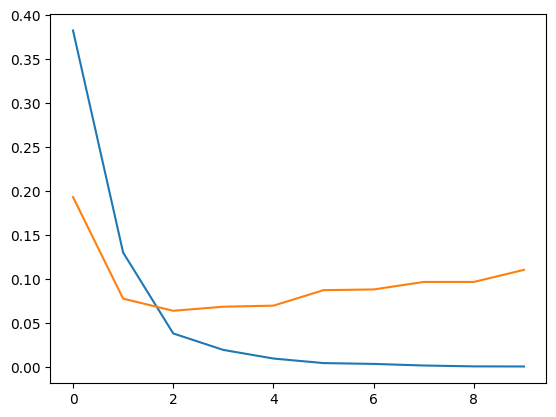

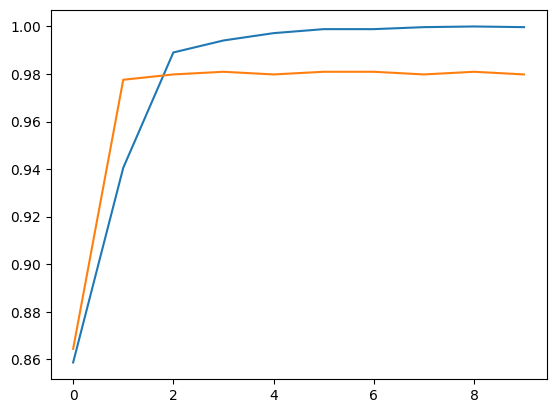

In [65]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


# Testing our model with custom input

In [67]:
def predict_sms(text):
    # Preprocess the input text similarly to how the training corpus was processed
    # Ensure 'ps' (WordNetLemmatizer) and 'stopwords' are accessible
    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()
    review = [ps.lemmatize(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)

    # Transform the preprocessed text using the fitted TfidfVectorizer (cv)
    # The model expects an input of the same shape as X_train
    processed_text_features = cv.transform([review]).toarray()

    prediction = model.predict(processed_text_features)[0][0]

    if prediction > 0.5:
        print("Spam Message")
    else:
        print("Ham Message")

# Example
predict_sms("Congratulations! You have won a free iPhone. Click here now!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Ham Message
